<a href="https://colab.research.google.com/github/Devikrishna545/MachineLearning_Practices/blob/main/Regression_in_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is to fit a line to several Data points  using pytorch **Auto differentiation**.

In [54]:
import torch
import matplotlib.pyplot as plt

In [55]:
# create a list of values as x
x=torch.tensor([1,2,3,4,5,6,7,8,9,10])  #dosage of drugs for alzhimers patients

The y values were created using the equation of a line y = mx+b
. This way, we know what the model parameters to be learned are, say, m = -0.5
 and b = 2
. Random, normally-distributed noise has been added to simulate sampling error:

In [56]:
y= -0.5 * x + 2 + torch.normal(mean=torch.zeros(10), std=0.2)

In [57]:
y

tensor([ 1.3434,  0.9356,  0.5945,  0.1982, -0.0987, -0.9574, -1.6330, -2.1997,
        -2.4947, -2.8259])

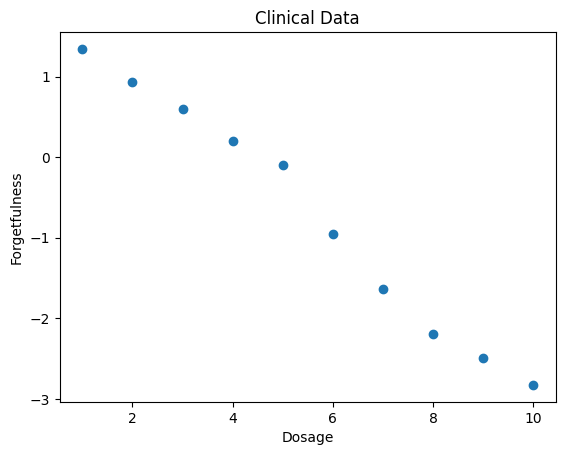

In [58]:
fig,ax = plt.subplots()
plt.title("Clinical Data")
plt.xlabel("Dosage")
plt.ylabel("Forgetfulness")
_=ax.scatter(x,y)




In [59]:
#Initialize the slope parameter with a "random" value of 0.9... and b as 0.1
#This tiny machine learning demo with two parameters and eight data points scales,
#however, to millions of parameters and millions of data points. The other approaches -- guessing, algebra, statistics -- do not come close to scaling in this way.)

In [60]:
m=torch.tensor(0.9).requires_grad_()
m

tensor(0.9000, requires_grad=True)

In [61]:
b=torch.tensor(0.1).requires_grad_()
b

tensor(0.1000, requires_grad=True)

In [62]:
def regression(my_m,my_x,my_b):
  return my_m * my_x + my_b

def regressionplot(my_m,my_x,my_b,my_y):
   fig, ax = plt.subplots()
   ax.scatter(my_x, my_y)

   x_min, x_max = ax.get_xlim()
   y_min = regression(x_min, my_m, my_b).detach().item()
   y_max = regression(x_max, my_m, my_b).detach().item()

   ax.set_xlim([x_min, x_max])
   _ = ax.plot([x_min, x_max], [y_min, y_max])

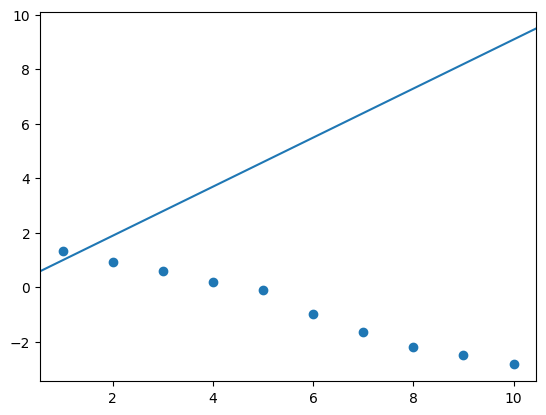

In [63]:
regressionplot(m,x,b,y)

In [64]:
#step-1
#forward pass

y_hat = regression(m,x,b)
y_hat

tensor([1.0000, 1.9000, 2.8000, 3.7000, 4.6000, 5.5000, 6.4000, 7.3000, 8.2000,
        9.1000], grad_fn=<AddBackward0>)

In [65]:
#step2 Calculate the Cost Function using mse method

def mse(my_y_hat,my_y):
  sigma= torch.sum((my_y_hat-my_y)**2)
  return sigma/len(my_y)

In [66]:
#Calculate cost function
C= mse(y_hat,y)
C

tensor(49.3326, grad_fn=<DivBackward0>)

In [67]:
#calculate the gradient of C using autodifferentiate
C.backward()

In [68]:
m.grad

tensor(86.4373)

In [69]:
b.grad

tensor(11.5275)

In [70]:
#step4:Gradient Descent Optimization

optimizer = torch.optim.SGD([m, b], lr=0.01)


In [71]:
optimizer.step()

In [72]:
m

tensor(0.0356, requires_grad=True)

In [73]:
b

tensor(-0.0153, requires_grad=True)

In [74]:
#to check cost has decreased
C = mse(regression(x, m, b), y)
C

tensor(3.1640, grad_fn=<DivBackward0>)

In [75]:
#Put the 4 steps in a loop to iteratively minimize cost toward zero:

epochs = 1000
for epoch in range (epochs):
      optimizer.zero_grad() # Reset gradients to zero; else they accumulate

      y_hat = regression(x, m, b) # Forward pass
      C = mse(y_hat, y) # Calculate cost function

      C.backward() # Calculate gradients
      optimizer.step()

      print('Epoch {}, cost {}, m grad {}, b grad {}'.format(epoch, '%.3g' % C.item(), '%.3g' % m.grad.item(), '%.3g' % b.grad.item()))



Epoch 0, cost 3.16, m grad 18.6, b grad 1.79
Epoch 1, cost 1.04, m grad 4.08, b grad -0.294
Epoch 2, cost 0.934, m grad 0.972, b grad -0.738
Epoch 3, cost 0.922, m grad 0.305, b grad -0.83
Epoch 4, cost 0.914, m grad 0.161, b grad -0.847
Epoch 5, cost 0.907, m grad 0.13, b grad -0.848
Epoch 6, cost 0.899, m grad 0.123, b grad -0.845
Epoch 7, cost 0.892, m grad 0.121, b grad -0.842
Epoch 8, cost 0.885, m grad 0.12, b grad -0.838
Epoch 9, cost 0.878, m grad 0.12, b grad -0.835
Epoch 10, cost 0.871, m grad 0.119, b grad -0.831
Epoch 11, cost 0.864, m grad 0.119, b grad -0.828
Epoch 12, cost 0.857, m grad 0.118, b grad -0.824
Epoch 13, cost 0.85, m grad 0.118, b grad -0.821
Epoch 14, cost 0.843, m grad 0.117, b grad -0.817
Epoch 15, cost 0.836, m grad 0.117, b grad -0.814
Epoch 16, cost 0.829, m grad 0.116, b grad -0.81
Epoch 17, cost 0.823, m grad 0.116, b grad -0.807
Epoch 18, cost 0.816, m grad 0.115, b grad -0.804
Epoch 19, cost 0.809, m grad 0.115, b grad -0.8
Epoch 20, cost 0.803, m 

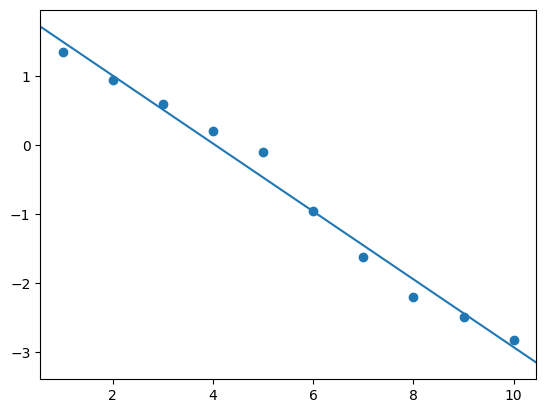

In [76]:
regressionplot(m,x,b,y)


In [77]:
m.item()

-0.4917035698890686

In [78]:
b.item()

1.9841597080230713